# Импорты и общие настройки

In [1]:
# Базовые библиотеки для воспроизводимости, анализа и удобного отображения результатов.
import random
from typing import Dict, List
from typing import Iterable
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import datasets
import transformers

from datasets import Dataset, DatasetDict
import torch.nn.functional as F
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

from transformers import (
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    AutoTokenizer,
    Trainer,
    pipeline,
    TrainingArguments,
)

pd.set_option("display.max_colwidth", 120)
pd.set_option("display.width", 180)
pd.set_option("display.precision", 4)

In [2]:
print(datasets.__version__)
print(transformers.__version__)
print(torch.__version__)

4.8.4
5.4.0
2.10.0+cu128


In [3]:
# Фиксируем seed и определяем устройство.
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.mps.manual_seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
pipeline_device = 0 if torch.cuda.is_available() else -1
print(f"Device: {device}")

# Берём стандартную мультиязычную BERT-модель: она хорошо подходит для русскоязычных примеров.
MODEL_NAME = "bert-base-multilingual-cased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print("Tokenizer loaded:", MODEL_NAME)
print("Tokenizer class:", tokenizer.__class__.__name__)
print("Model max length:", tokenizer.model_max_length)

Device: cuda


Tokenizer loaded: bert-base-multilingual-cased
Tokenizer class: BertTokenizer
Model max length: 512


# Артефакты

In [4]:
artifacts_dir = Path("artifacts")
figures_dir = artifacts_dir / "figures"
def save_json(obj: dict, path: Path):
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", encoding="utf-8") as f:
        json.dump(obj, f, ensure_ascii=False, indent=2)

# Данные и первичный анализ

In [5]:
df_train = pd.read_csv("./data/training.csv")
df_val = pd.read_csv("./data/validation.csv")
df_test = pd.read_csv("./data/test.csv")

In [6]:
# anger, fear, joy, love, sadness, and surprise
print("Размер датасета: ", len(df_train)+len(df_val)+len(df_test))
print("Размер train: ", len(df_train))
print("Размер val: ", len(df_val))
print("Размер test: ", len(df_test))
display(df_train["label"].value_counts())
display(df_val["label"].value_counts())
display(df_test["label"].value_counts())

Размер датасета:  20000
Размер train:  16000
Размер val:  2000
Размер test:  2000


label
1    5362
0    4666
3    2159
4    1937
2    1304
5     572
Name: count, dtype: int64

label
1    704
0    550
3    275
4    212
2    178
5     81
Name: count, dtype: int64

label
1    695
0    581
3    275
4    224
2    159
5     66
Name: count, dtype: int64

In [7]:
label_names = sorted(df_train["label"].unique())
id2label = {
  "sadness": 0,
  "joy": 1,
  "love": 2,
  "anger": 3,
  "fear": 4,
  "surprise": 5
}
label2text = {label: text for text, label in id2label.items()}
df_train["label_text"] = df_train["label"].map(label2text)
df_val["label_text"] = df_val["label"].map(label2text)
df_test["label_text"] = df_test["label"].map(label2text)
print("id2label:", id2label)
print("label2text:", label2text)
display(df_train.sample(6, random_state=42).reset_index(drop=True))
display(df_val.sample(6, random_state=42).reset_index(drop=True))
display(df_test.sample(6, random_state=42).reset_index(drop=True))
emotions = [ "sadness", "joy", "love", "anger", "fear", "surprise"]

id2label: {'sadness': 0, 'joy': 1, 'love': 2, 'anger': 3, 'fear': 4, 'surprise': 5}
label2text: {0: 'sadness', 1: 'joy', 2: 'love', 3: 'anger', 4: 'fear', 5: 'surprise'}


,text,label,label_text
0,ive made it through a week i just feel beaten down,0,sadness
1,i feel this strategy is worthwhile,1,joy
2,i feel so worthless and weak what does he have to say that s what i want to find out,0,sadness
3,i feel clever nov,1,joy
4,im moved in ive been feeling kind of gloomy,0,sadness
5,i allowed myself to feel the really shitty feelings while i was running because a the endorphins were flowing so it ...,0,sadness


,text,label,label_text
0,i really feel like writing about or supporting their product in the payperpost marketplace,2,love
1,im trying to wein off them with doctors guidance of course but if i miss a day i feel agitated about everything,4,fear
2,i am continually having to dig deep within myself to push forward to do more and right now im feeling an awful like ...,0,sadness
3,i want to commit to continuing to post here once a week or so but i want those posts to only be about books i feel c...,1,joy
4,im feeling very distracted today,3,anger
5,i wanted to pen it down for memory sake but i was still feeling extremely emotional days after the episode and had n...,0,sadness


,text,label,label_text
0,i feel so dirty but after spending a day at the mk show me and a buddy decided we would get the two player starter b...,0,sadness
1,i could feel his breath on me and smell the sweet scent of him,1,joy
2,i just want to feel loved by you,2,love
3,i have felt the need to write out my sometimes anxious feelings impatient thoughts lists of things that still should...,3,anger
4,at a party i met a girl who drew me to her,3,anger
5,i feel this strange sort of liberation,5,surprise


### Классифицируется тональность текста. Всего 6 классов.

In [8]:
special_tokens_df = pd.DataFrame(
    {
        "name": [
            "cls_token",
            "sep_token",
            "pad_token",
            "unk_token",
            "mask_token",
        ],
        "token": [
            tokenizer.cls_token,
            tokenizer.sep_token,
            tokenizer.pad_token,
            tokenizer.unk_token,
            tokenizer.mask_token,
        ],
        "token_id": [
            tokenizer.cls_token_id,
            tokenizer.sep_token_id,
            tokenizer.pad_token_id,
            tokenizer.unk_token_id,
            tokenizer.mask_token_id,
        ],
    }
)
display(special_tokens_df)

,name,token,token_id
0,cls_token,[CLS],101
1,sep_token,[SEP],102
2,pad_token,[PAD],0
3,unk_token,[UNK],100
4,mask_token,[MASK],103


In [9]:
encoded_with_specials = tokenizer(
    df_train["text"][0],
    add_special_tokens=True,
    return_attention_mask=True,
    return_token_type_ids=True,
)
encoded_padding = tokenizer(
    [i for i in df_train["text"]],
    padding=True,
    return_tensors="pt",
)
full_ids = encoded_with_specials["input_ids"]
full_tokens = tokenizer.convert_ids_to_tokens(full_ids)

display(
    pd.DataFrame(
        {
            "position": list(range(len(full_ids))),
            "token": full_tokens,
            "token_id": full_ids,
            "attention_mask": encoded_with_specials["attention_mask"],
            "token_type_id": encoded_with_specials["token_type_ids"],
        }
    )
)

# padding

pad_ids = encoded_padding["input_ids"][0].tolist()
pad_tokens = tokenizer.convert_ids_to_tokens(pad_ids)
pad_mask = encoded_padding["attention_mask"][0].tolist()
display(
    pd.DataFrame(
        {
            "position": list(range(len(pad_ids))),
            "token": pad_tokens,
            "token_id": pad_ids,
            "attention_mask": pad_mask,
        }
    )
)

,position,token,token_id,attention_mask,token_type_id
0,0,[CLS],101,1,0
1,1,i,177,1,0
2,2,didn,34420,1,0
3,3,##t,10123,1,0
4,4,feel,38008,1,0
5,5,hu,26506,1,0
6,6,##mil,55177,1,0
7,7,##iated,89771,1,0
8,8,[SEP],102,1,0


,position,token,token_id,attention_mask
0,0,[CLS],101,1
1,1,i,177,1
2,2,didn,34420,1
3,3,##t,10123,1
4,4,feel,38008,1
...,...,...,...,...
78,78,[PAD],0,0
79,79,[PAD],0,0
80,80,[PAD],0,0
81,81,[PAD],0,0


In [10]:
train_ds = Dataset.from_pandas(
    df_train[["text", "label"]].rename(columns={"label": "labels"}).reset_index(drop=True),
    preserve_index=False,
)
val_ds = Dataset.from_pandas(
    df_val[["text", "label"]].rename(columns={"label": "labels"}).reset_index(drop=True),
    preserve_index=False,
)
test_ds = Dataset.from_pandas(
    df_test[["text", "label"]].rename(columns={"label": "labels"}).reset_index(drop=True),
    preserve_index=False,
)

dataset_dict = DatasetDict({
    "train": train_ds,
    "validation": val_ds,
    "test": test_ds,
})

dataset_dict

DatasetDict({
    train: Dataset({
        features: ['text', 'labels'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'labels'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'labels'],
        num_rows: 2000
    })
})

In [11]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print("Tokenizer loaded:", tokenizer.__class__.__name__)
print("Model checkpoint:", MODEL_NAME)

def tokenize_batch(batch: Dict[str, List[str]]) -> Dict[str, List[List[int]]]:
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=128,
    )

tokenized_datasets = dataset_dict.map(tokenize_batch, batched=True)

# Удаляем столбец "text": DataCollatorWithPadding попытается преобразовать
# все поля датасета в тензоры, а строки в тензор не конвертируются.
tokenized_datasets = tokenized_datasets.remove_columns(["text"])
tokenized_datasets

Tokenizer loaded: BertTokenizer
Model checkpoint: bert-base-multilingual-cased


Map:   0%|          | 0/16000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
})

In [12]:
example = tokenized_datasets["train"][0]
print("Ключи примера:", example.keys())
print("labels:", example["labels"])
print("input_ids[:20]:", example["input_ids"][:20])
print("attention_mask[:20]:", example["attention_mask"][:20])

print("\nДекодированный текст по input_ids:")
print(tokenizer.decode(example["input_ids"]))

Ключи примера: dict_keys(['labels', 'input_ids', 'token_type_ids', 'attention_mask'])
labels: 0
input_ids[:20]: [101, 177, 34420, 10123, 38008, 26506, 55177, 89771, 102]
attention_mask[:20]: [1, 1, 1, 1, 1, 1, 1, 1, 1]

Декодированный текст по input_ids:
[CLS] i didnt feel humiliated [SEP]


# Инференс готовой модели

In [13]:
# Создаём high-level pipeline для классификации текста.
id2label = {
  "sadness": 0,
  "joy": 1,
  "love": 2,
  "anger": 3,
  "fear": 4,
  "surprise": 5
}
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME).to(device)
model.eval()
text_clf = pipeline(
    task="text-classification",
    model=model,
    tokenizer=tokenizer,
    device=pipeline_device,
)

pipeline_outputs = text_clf(df_train["text"].iloc[0:8].tolist())

pipeline_df = pd.DataFrame(
    {
        "text": df_train["text"].iloc[0:8],
        "predicted_label": [item["label"] for item in pipeline_outputs],
        "score": [item["score"] for item in pipeline_outputs],
    }
)

pipeline_df

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


,text,predicted_label,score
0,i didnt feel humiliated,LABEL_1,0.5118
1,i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake,LABEL_1,0.5185
2,im grabbing a minute to post i feel greedy wrong,LABEL_1,0.5052
3,i am ever feeling nostalgic about the fireplace i will know that it is still on the property,LABEL_1,0.5208
4,i am feeling grouchy,LABEL_1,0.5282
5,ive been feeling a little burdened lately wasnt sure why that was,LABEL_0,0.5004
6,ive been taking or milligrams or times recommended amount and ive fallen asleep a lot faster but i also feel like so...,LABEL_1,0.5230
7,i feel as confused about life as a teenager or as jaded as a year old man,LABEL_1,0.5119


#### Судя по уверенности модели можно сделать вывод, что она не подходит под выбранную задачу. Во-первых - она практически угадывает правильную метку, а во-вторых в большинстве случаев - неверно.

# Fine-tuning для классификации текста

In [14]:
# Data collator будет добавлять padding динамически, прямо при формировании батча.
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

sample_batch = [tokenized_datasets["train"][i] for i in range(3)]
collated_batch = data_collator(sample_batch)

for key, value in collated_batch.items():
    print(f"{key}: shape={tuple(value.shape)}")

labels: shape=(3,)
input_ids: shape=(3, 28)
token_type_ids: shape=(3, 28)
attention_mask: shape=(3, 28)


In [15]:
# Загружаем модель для классификации.
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(label_names),
    id2label=label2text,
    label2id=id2label,
    ignore_mismatched_sizes=True,
)

model.to(device)

print("Model class:", model.__class__.__name__)
print("Number of labels:", model.config.num_labels)
print("id2label:", model.config.id2label)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model class: BertForSequenceClassification
Number of labels: 6
id2label: {0: 'sadness', 1: 'joy', 2: 'love', 3: 'anger', 4: 'fear', 5: 'surprise'}


In [16]:
# Функция метрик для Trainer.
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    acc = accuracy_score(labels, preds)
    f1_macro = f1_score(labels, preds, average="macro")
    f1_weighted = f1_score(labels, preds, average="weighted")

    return {
        "accuracy": acc,
        "f1_macro": f1_macro,
        "f1_weighted": f1_weighted,
    }


In [17]:
# Общие параметры обучения.
common_training_kwargs = dict(
    output_dir="outputs/s13_bert_finetuning_demo",
    learning_rate=2e-5,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    num_train_epochs=5,
    weight_decay=0.01,
    logging_steps=2,
    save_total_limit=1,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    report_to="none",
)

try:
    training_args = TrainingArguments(
        evaluation_strategy="epoch",
        save_strategy="epoch",
        **common_training_kwargs,
    )
except TypeError:
    training_args = TrainingArguments(
        eval_strategy="epoch",
        save_strategy="epoch",
        **common_training_kwargs,
    )

training_args


TrainingArguments(
accelerator_config={'split_batches': False, 'dispatch_batches': None, 'even_batches': True, 'use_seedable_sampler': True, 'non_blocking': False, 'gradient_accumulation_kwargs': None, 'use_configured_state': False},
adam_beta1=0.9,
adam_beta2=0.999,
adam_epsilon=1e-08,
auto_find_batch_size=False,
average_tokens_across_devices=True,
batch_eval_metrics=False,
bf16=False,
bf16_full_eval=False,
data_seed=None,
dataloader_drop_last=False,
dataloader_num_workers=0,
dataloader_persistent_workers=False,
dataloader_pin_memory=True,
dataloader_prefetch_factor=None,
ddp_backend=None,
ddp_broadcast_buffers=None,
ddp_bucket_cap_mb=None,
ddp_find_unused_parameters=None,
ddp_timeout=1800,
debug=[],
deepspeed=None,
disable_tqdm=False,
do_eval=True,
do_predict=False,
do_train=False,
enable_jit_checkpoint=False,
eval_accumulation_steps=None,
eval_delay=0,
eval_do_concat_batches=True,
eval_on_start=False,
eval_steps=None,
eval_strategy=IntervalStrategy.EPOCH,
eval_use_gather_object=Fals

In [18]:
# Собираем Trainer и запускаем обучение.
# В transformers >= 5.0 аргумент tokenizer переименован в processing_class.
try:
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_datasets["train"],
        eval_dataset=tokenized_datasets["validation"],
        processing_class=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )
except TypeError:
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_datasets["train"],
        eval_dataset=tokenized_datasets["validation"],
        tokenizer=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )

train_result = trainer.train()
train_result


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
1,0.105553,0.339989,0.912000,0.885800,0.912396
2,0.265981,0.295012,0.920000,0.891331,0.918712
3,0.000449,0.280205,0.933000,0.907717,0.933126
4,0.000404,0.321330,0.933500,0.908861,0.933640
5,0.000403,0.361133,0.930500,0.901745,0.930686


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=20000, training_loss=0.2808868927754316, metrics={'train_runtime': 1088.9355, 'train_samples_per_second': 73.466, 'train_steps_per_second': 18.367, 'total_flos': 1589757645163392.0, 'train_loss': 0.2808868927754316, 'epoch': 5.0})

In [19]:
print(f"лучший шаг (эпоха): {trainer.state.best_global_step}") # 4
print(f"лучшая метрика для лучшей эпохи: {trainer.state.best_metric}")

лучший шаг (эпоха): 16000
лучшая метрика для лучшей эпохи: 0.9088614210354177


In [20]:
# История логов Trainer.
history_df = pd.DataFrame(trainer.state.log_history)
display(history_df.tail(10))

,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_accuracy,eval_f1_macro,eval_f1_weighted,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
9996,0.0026,3.3166,1.5000e-08,4.9965,19986,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9997,0.0002,0.0040,1.3000e-08,4.9970,19988,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9998,0.0002,0.0027,1.1000e-08,4.9975,19990,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9999,0.1277,10.1627,9.0000e-09,4.9980,19992,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10000,0.2752,315.8341,7.0000e-09,4.9985,19994,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10001,0.0003,0.0438,5.0000e-09,4.9990,19996,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10002,0.0003,0.0065,3.0000e-09,4.9995,19998,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10003,0.0004,0.0044,1.0000e-09,5.0000,20000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10004,NaN,NaN,NaN,5.0000,20000,0.3611,0.9305,0.9017,0.9307,3.3099,604.256,151.064,NaN,NaN,NaN,NaN,NaN
10005,NaN,NaN,NaN,5.0000,20000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1088.9355,73.466,18.367,1.5898e+15,0.2809


In [21]:
# В transformers >= 5.x NotebookProgressCallback теряет состояние после обучения,
# что вызывает RuntimeError при вызове evaluate() вне тренировочного цикла.
# Удаляем его перед standalone-оценкой – это стандартный обходной путь.
from transformers.utils.notebook import NotebookProgressCallback
trainer.remove_callback(NotebookProgressCallback)

# Оценка Trainer на validation и test.
val_metrics = trainer.evaluate(tokenized_datasets["validation"])
test_metrics = trainer.evaluate(tokenized_datasets["test"])

print("Validation metrics:")
for k, v in val_metrics.items():
    print(f"{k}: {v:.4f}" if isinstance(v, (int, float)) else f"{k}: {v}")

print("\nTest metrics:")
for k, v in test_metrics.items():
    print(f"{k}: {v:.4f}" if isinstance(v, (int, float)) else f"{k}: {v}")


Validation metrics:
eval_loss: 0.3212
eval_accuracy: 0.9340
eval_f1_macro: 0.9091
eval_f1_weighted: 0.9341
eval_runtime: 3.1551
eval_samples_per_second: 633.9030
eval_steps_per_second: 158.4760
epoch: 5.0000

Test metrics:
eval_loss: 0.3464
eval_accuracy: 0.9230
eval_f1_macro: 0.8784
eval_f1_weighted: 0.9218
eval_runtime: 3.3017
eval_samples_per_second: 605.7540
eval_steps_per_second: 151.4380
epoch: 5.0000


Classification report on test:
              precision    recall  f1-score   support

     sadness       0.95      0.97      0.96       581
         joy       0.94      0.95      0.95       695
        love       0.87      0.75      0.81       159
       anger       0.95      0.89      0.92       275
        fear       0.84      0.96      0.90       224
    surprise       0.85      0.67      0.75        66

    accuracy                           0.92      2000
   macro avg       0.90      0.86      0.88      2000
weighted avg       0.92      0.92      0.92      2000



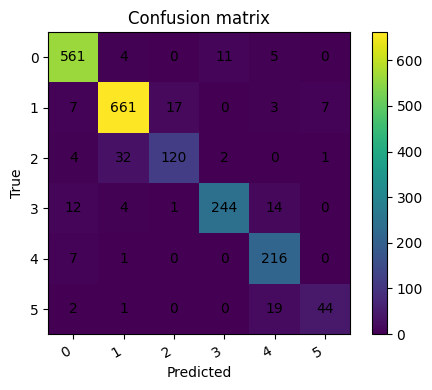

In [22]:
# Детальные предсказания на тестовой выборке.
test_output = trainer.predict(tokenized_datasets["test"])
test_logits = test_output.predictions
test_preds = np.argmax(test_logits, axis=-1)
test_true = test_output.label_ids

print("Classification report on test:")
print(
    classification_report(
        test_true,
        test_preds,
        target_names=[label2text[i] for i in range(len(id2label))],
        zero_division=0,
    )
)

cm = confusion_matrix(test_true, test_preds)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm)

ax.set_xticks(range(len(label_names)))
ax.set_yticks(range(len(label_names)))
ax.set_xticklabels(label_names, rotation=30, ha="right")
ax.set_yticklabels(label_names)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion matrix")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig(artifacts_dir/"confusion_matrix.png")
plt.show()


In [23]:
# Таблица ошибок на тестовой выборке.
test_texts = df_test.reset_index(drop=True)["text"]
error_rows = []

for text, true_id, pred_id, prob_vector in zip(test_texts, test_true, test_preds, torch.softmax(torch.tensor(test_logits), dim=-1).numpy()):
    if true_id != pred_id:
        error_rows.append({
            "text": text,
            "true_label": label2text[int(true_id)],
            "pred_label": label2text[int(pred_id)],
            "confidence": float(prob_vector[pred_id]),
        })

errors_df = pd.DataFrame(error_rows)

if len(errors_df) == 0:
    print("На тестовой выборке ошибок не найдено. Это возможно на маленьком учебном датасете.")
else:
    display(errors_df.sort_values(by="confidence", ascending=False).reset_index(drop=True))
# примеры предсказаний модели
sample_rows = []
test_texts = df_test.reset_index(drop=True)["text"].tolist()
for text, true_id, pred_id, prob_vector in zip(test_texts[0:10], test_true[0:10], test_preds[0:10], torch.softmax(torch.tensor(test_logits[0:10]), dim=-1).numpy()):
    sample_rows.append({
        "text": text,
        "true_label": label2text[int(true_id)],
        "pred_label": label2text[int(pred_id)],
        "confidence": float(prob_vector[pred_id]),
    })

sample_df = pd.DataFrame(sample_rows)
display(sample_df)
sample_df.to_csv(artifacts_dir / "sample_predictions.csv", index=False)

,text,true_label,pred_label,confidence
0,i cant help feeling this way,sadness,joy,0.9998
1,i feel cared for and accepted,love,joy,0.9998
2,i feel i should as a gracious gesture apologizing for my latest post about the osp and the rand license terms,love,joy,0.9998
3,im so proud of you no words can describe the way that makes my heart feel thank you god for my supportive amazing hu...,love,joy,0.9998
4,whenever i put myself in others shoes and try to make the person happy,anger,joy,0.9998
...,...,...,...,...
149,i know how it feels to be tortured,anger,fear,0.5264
150,i feel totally completely accepted and loved while my heavenly abba was pointing out sin in my life,love,joy,0.5117
151,i felt like id developed feelings for this guy thus explaining why id even follow this guy like a faithful puppy dog...,joy,love,0.5105
152,i ever recognized what it was to feel passionate about something was with music,love,joy,0.5075


,text,true_label,pred_label,confidence
0,im feeling rather rotten so im not very ambitious right now,sadness,sadness,0.9998
1,im updating my blog because i feel shitty,sadness,sadness,0.9998
2,i never make her separate from me because i don t ever want her to feel like i m ashamed with her,sadness,sadness,0.9998
3,i left with my bouquet of red and yellow tulips under my arm feeling slightly more optimistic than when i arrived,joy,joy,0.9997
4,i was feeling a little vain when i did this one,sadness,sadness,0.9998
5,i cant walk into a shop anywhere where i do not feel uncomfortable,fear,fear,0.9997
6,i felt anger when at the end of a telephone call,anger,anger,0.6747
7,i explain why i clung to a relationship with a boy who was in many ways immature and uncommitted despite the excitem...,joy,joy,0.9558
8,i like to have the same breathless feeling as a reader eager to see what will happen next,joy,joy,0.9998
9,i jest i feel grumpy tired and pre menstrual which i probably am but then again its only been a week and im about as...,anger,anger,0.9996


### Местами модель путала негативные тексты с позитивными. Но чаще модель ошибалась на близких эмоциях. Например, "i feel cared for and accepted" модель определила как joy, но по true_label - это love. Например, "i can't help feeling this way" модель распознала как sadness. Возможно, она не поняла речевой оборот "i can't help" и восприняла его буквально как "я не способен помочь". Или "i feel i should as a gracious gesture apologizing for my latest post about the osp and the rand license terms" модель восприняла как "love".